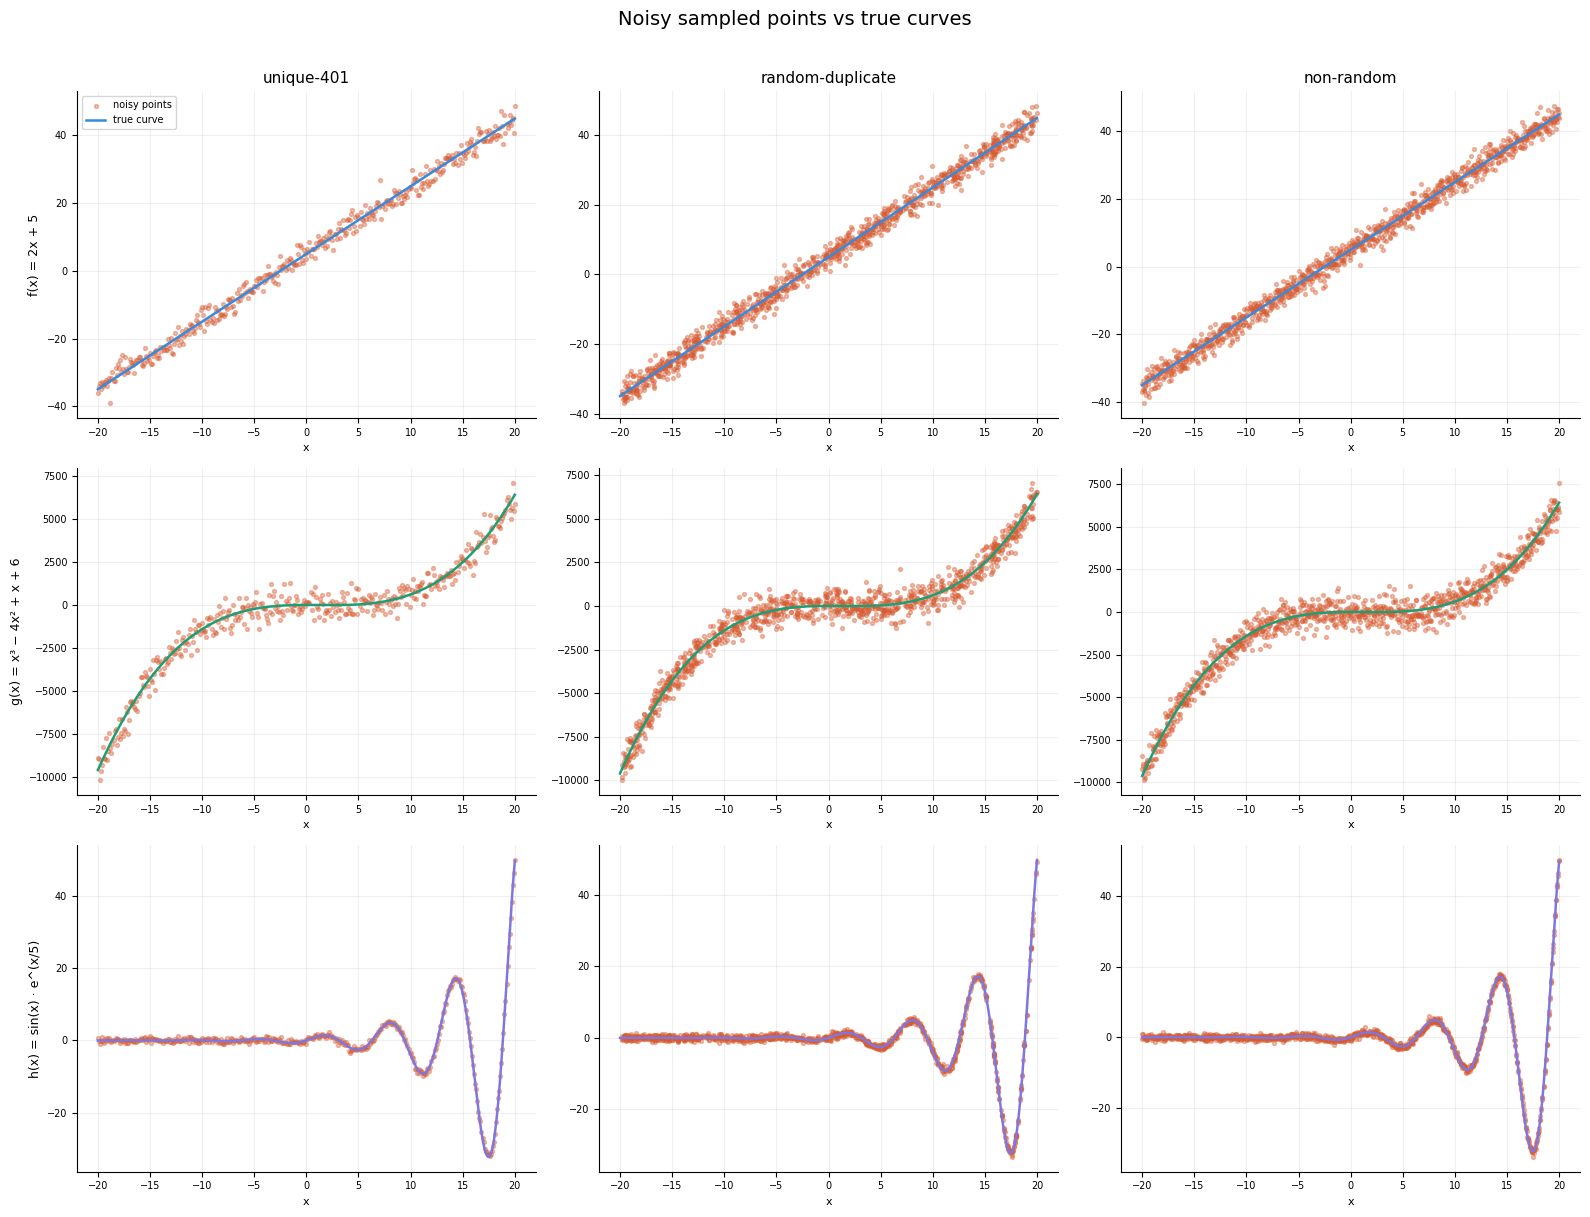

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- True curves ---
x_true = np.linspace(-20, 20, 500)
true_curves = {
    'f_linear':     2 * x_true + 5,
    'g_polynomial': x_true**3 - 4*x_true**2 + x_true + 6,
    'h_challenge':  np.sin(x_true) * np.exp(x_true / 5),
}

true_colors = {
    'f_linear':     '#378ADD',
    'g_polynomial': '#1D9E75',
    'h_challenge':  '#7F77DD',
}

labels = {
    'f_linear':     'f(x) = 2x + 5',
    'g_polynomial': 'g(x) = x³ − 4x² + x + 6',
    'h_challenge':  'h(x) = sin(x) · e^(x/5)',
}

# --- Load noisy datasets ---
datasets = {
    'unique-401':       pd.read_csv('unique-401-noisy.csv'),
    'random-duplicate': pd.read_csv('random-duplicate-noisy.csv'),
    'non-random':       pd.read_csv('non-random-noisy.csv'),
}

# --- Plot: 3 rows (functions) x 3 cols (datasets) ---
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Noisy sampled points vs true curves', fontsize=14, fontweight='normal', y=1.01)

for row, col_name in enumerate(['f_linear', 'g_polynomial', 'h_challenge']):
    for col, (ds_name, df) in enumerate(datasets.items()):

        ax = axes[row][col]
        df_sorted = df.sort_values('x')

        # Scatter: noisy sampled points
        ax.scatter(df_sorted['x'], df_sorted[col_name],
                   color='#D85A30', alpha=0.4, s=8, label='noisy points')

        # Line: true clean curve
        ax.plot(x_true, true_curves[col_name],
                color=true_colors[col_name], linewidth=1.8, label='true curve')

        if row == 0:
            ax.set_title(ds_name, fontsize=11, fontweight='normal')
        if col == 0:
            ax.set_ylabel(labels[col_name], fontsize=9)

        ax.set_xlabel('x', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.2)
        ax.spines[['top', 'right']].set_visible(False)

        if row == 0 and col == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('noisy_vs_true.png', dpi=150, bbox_inches='tight')
plt.show()



f_linear — model 1 recovered equation:
  y = 5.116 + 1.985·x^1
  R² scores on test set:
    Poly regression: 0.9939
    Random forest: 0.9905
    Neural net: 0.9924


/opt/conda/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (5000) reached and the optimization hasn't converged yet.
  warnings.warn(



g_polynomial — model 1 recovered equation:
  y = 27.343 + 4.515·x^1 + -4.331·x^2 + 0.995·x^3
  R² scores on test set:
    Poly regression: 0.9782
    Random forest: 0.9744
    Neural net: 0.1670

h_challenge — model 1 recovered equation:
  y = 2.439 + -1.012·x^1 + -0.286·x^2 + 0.026·x^3 + 0.005·x^4 + -0.000·x^5 + -0.000·x^6 + 0.000·x^7 + 0.000·x^8
  R² scores on test set:
    Poly regression: 0.7004
    Random forest: 0.9863
    Neural net: -0.2186


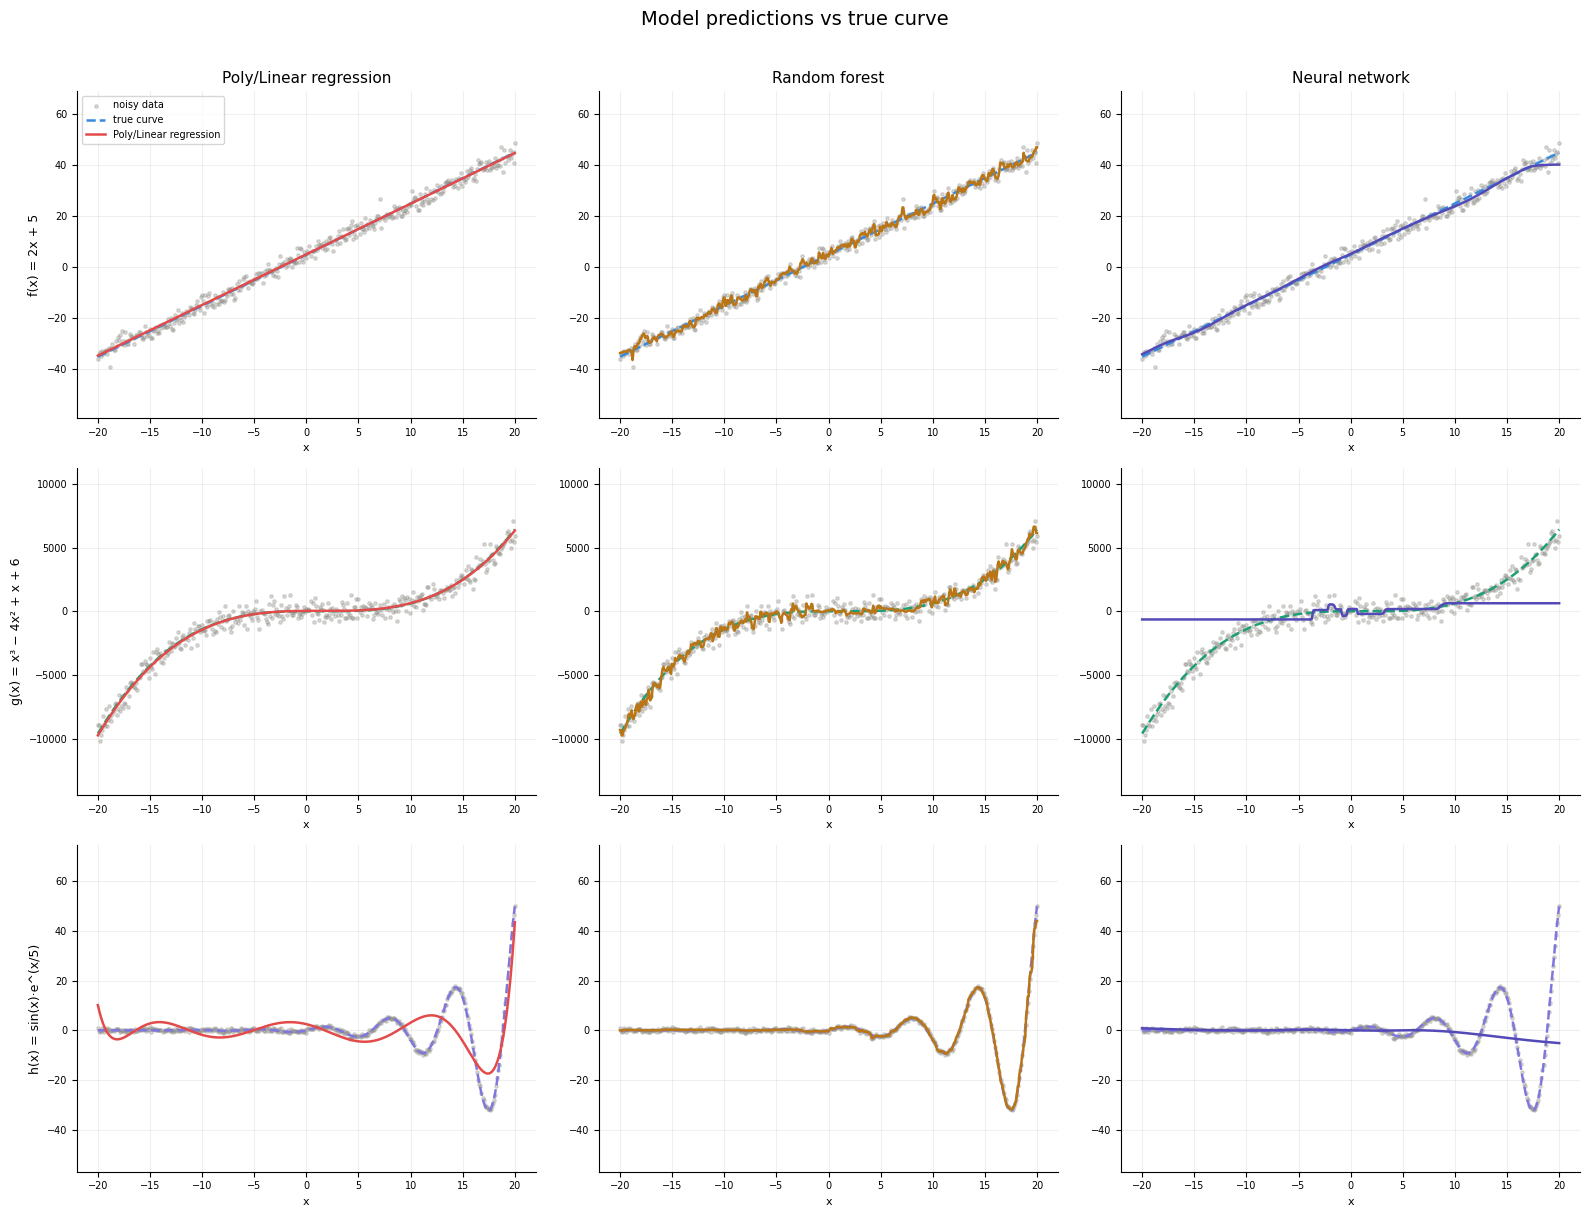

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# --- Load data (using unique-401 noisy as example, swap as needed) ---
df = pd.read_csv('unique-401-noisy.csv').sort_values('x').reset_index(drop=True)

X = df[['x']].values
x_plot = np.linspace(-20, 20, 500).reshape(-1, 1)

# --- True curves for comparison ---
def true_linear(x):    return 2*x + 5
def true_poly(x):      return x**3 - 4*x**2 + x + 6
def true_challenge(x): return np.sin(x) * np.exp(x/5)

functions = {
    'f_linear':     (df['f_linear'].values,     true_linear,    '#378ADD'),
    'g_polynomial': (df['g_polynomial'].values, true_poly,      '#1D9E75'),
    'h_challenge':  (df['h_challenge'].values,  true_challenge, '#7F77DD'),
}

func_labels = {
    'f_linear':     'f(x) = 2x + 5',
    'g_polynomial': 'g(x) = x³ − 4x² + x + 6',
    'h_challenge':  'h(x) = sin(x)·e^(x/5)',
}

# ---------------------------------------------------------------
# MODEL 1 — Linear / Polynomial regression
# Approach: expand features to [x, x², x³] then fit least squares
# Recovers interpretable coefficients — closest to the real equation
# ---------------------------------------------------------------
def model1(X_train, y_train, degree):
    m = make_pipeline(PolynomialFeatures(degree=degree), LinearRegression())
    m.fit(X_train, y_train)
    return m

# ---------------------------------------------------------------
# MODEL 2 — Random forest
# Approach: ensemble of 200 decision trees, each trained on a
# random subset of data. Averages their predictions.
# No equation output but robust to noise.
# ---------------------------------------------------------------
def model2(X_train, y_train):
    m = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
    m.fit(X_train, y_train)
    return m

# ---------------------------------------------------------------
# MODEL 3 — Neural network (MLP)
# Approach: 3 hidden layers of 64 neurons with tanh activation.
# Can approximate any smooth function including sinusoids.
# ---------------------------------------------------------------
def model3(X_train, y_train):
    m = MLPRegressor(hidden_layer_sizes=(64, 64, 64), activation='tanh',
                     max_iter=5000, random_state=42, learning_rate_init=0.001)
    m.fit(X_train, y_train)
    return m

# --- Polynomial degrees per function ---
poly_degrees = {
    'f_linear':     1,
    'g_polynomial': 3,
    'h_challenge':  8,   # high degree to approximate sinusoid — will extrapolate poorly
}

# --- Plot 3 rows x 3 cols ---
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Model predictions vs true curve', fontsize=14, fontweight='normal', y=1.01)

model_colors = {
    'Poly/Linear regression': '#E24B4A',
    'Random forest':          '#BA7517',
    'Neural network':         '#534AB7',
}

for row, (fn_name, (y, true_fn, true_color)) in enumerate(functions.items()):

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    degree = poly_degrees[fn_name]
    m1 = model1(X_train, y_train, degree=degree)
    m2 = model2(X_train, y_train)
    m3 = model3(X_train, y_train)

    preds = {
        'Poly/Linear regression': m1.predict(x_plot),
        'Random forest':          m2.predict(x_plot),
        'Neural network':         m3.predict(x_plot),
    }

    # --- Print recovered equation for model 1 ---
    coefs = m1.named_steps['linearregression'].coef_
    intercept = m1.named_steps['linearregression'].intercept_
    terms = [f'{intercept:.3f}'] + [f'{c:.3f}·x^{i+1}' for i, c in enumerate(coefs[1:])]
    print(f'\n{fn_name} — model 1 recovered equation:')
    print('  y = ' + ' + '.join(terms))

    # --- R² scores on test set ---
    print(f'  R² scores on test set:')
    for mname, model in [('Poly regression', m1), ('Random forest', m2), ('Neural net', m3)]:
        r2 = r2_score(y_test, model.predict(X_test))
        print(f'    {mname}: {r2:.4f}')

    for col, (model_name, pred) in enumerate(preds.items()):
        ax = axes[row][col]

        # Noisy scatter
        ax.scatter(X, y, color='#888780', alpha=0.3, s=6, label='noisy data')

        # True curve
        ax.plot(x_plot, true_fn(x_plot), color=true_color,
                linewidth=1.8, linestyle='--', label='true curve')

        # Model prediction
        ax.plot(x_plot, pred, color=model_colors[model_name],
                linewidth=1.8, label=model_name)

        if row == 0:
            ax.set_title(model_name, fontsize=11, fontweight='normal')
        if col == 0:
            ax.set_ylabel(func_labels[fn_name], fontsize=9)

        ax.set_xlabel('x', fontsize=8)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.2)
        ax.spines[['top', 'right']].set_visible(False)

        # Clip y axis so polynomial extremes don't crush other functions
        y_true = true_fn(x_plot.flatten())
        margin = (y_true.max() - y_true.min()) * 0.3
        ax.set_ylim(y_true.min() - margin, y_true.max() + margin)

        if row == 0 and col == 0:
            ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('model_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

R² scores:
                  Poly/Linear regression  Random forest  Neural network
f(x) linear                      0.9939         0.9905          0.9940
g(x) polynomial                  0.9782         0.9744          0.9791
h(x) challenge                   0.7004         0.9863         -0.0597

RMSE scores:
                  Poly/Linear regression  Random forest  Neural network
f(x) linear                      1.9188         2.4062          1.9058
g(x) polynomial                529.2923       574.0016        519.1104
h(x) challenge                   5.6443         1.2050         10.6147


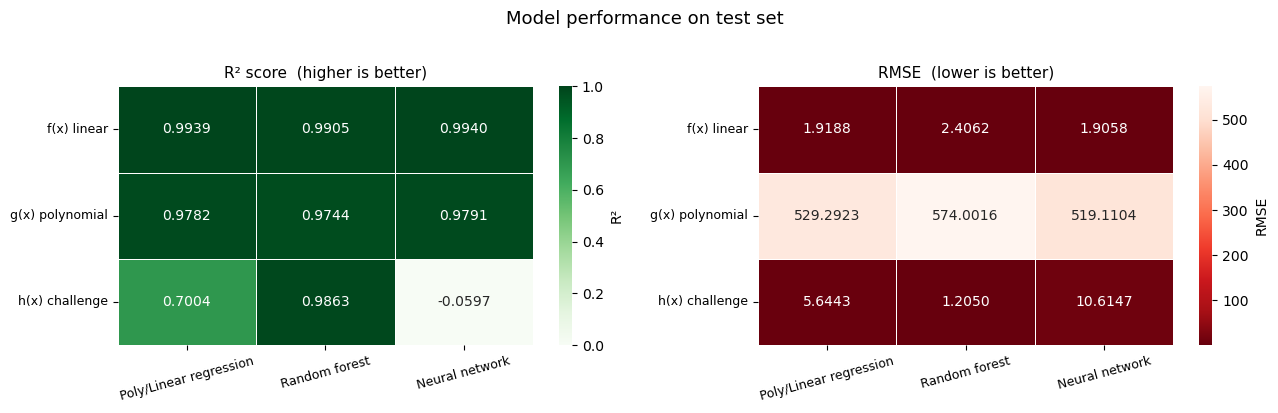

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# --- Load data ---
df = pd.read_csv('unique-401-noisy.csv').sort_values('x').reset_index(drop=True)
X = df[['x']].values

functions = {
    'f(x) linear':     df['f_linear'].values,
    'g(x) polynomial': df['g_polynomial'].values,
    'h(x) challenge':  df['h_challenge'].values,
}

poly_degrees = {
    'f(x) linear':     1,
    'g(x) polynomial': 3,
    'h(x) challenge':  8,
}

models_list = ['Poly/Linear regression', 'Random forest', 'Neural network']
r2_scores   = pd.DataFrame(index=list(functions.keys()), columns=models_list, dtype=float)
rmse_scores = pd.DataFrame(index=list(functions.keys()), columns=models_list, dtype=float)

for fn_name, y in functions.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Scale BOTH X and y going into the neural network
    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_sc = x_scaler.fit_transform(X_train)
    X_test_sc  = x_scaler.transform(X_test)
    y_train_sc = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()

    # Model 1 — polynomial/linear regression (no scaling needed)
    m1 = make_pipeline(PolynomialFeatures(degree=poly_degrees[fn_name]), LinearRegression())
    m1.fit(X_train, y_train)
    preds_m1 = m1.predict(X_test)

    # Model 2 — random forest (no scaling needed)
    m2 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
    m2.fit(X_train, y_train)
    preds_m2 = m2.predict(X_test)

    # Model 3 — neural network (scaled X and y)
    m3 = MLPRegressor(
        hidden_layer_sizes=(128, 128, 64),
        activation='tanh',
        max_iter=20000,
        random_state=42,
        learning_rate='adaptive',
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=100,
        tol=1e-6,
    )
    m3.fit(X_train_sc, y_train_sc)
    preds_m3 = y_scaler.inverse_transform(
        m3.predict(X_test_sc).reshape(-1, 1)
    ).ravel()

    for model_name, preds in zip(models_list, [preds_m1, preds_m2, preds_m3]):
        r2_scores.loc[fn_name, model_name]   = round(r2_score(y_test, preds), 4)
        rmse_scores.loc[fn_name, model_name] = round(np.sqrt(mean_squared_error(y_test, preds)), 4)

print('R² scores:\n', r2_scores)
print('\nRMSE scores:\n', rmse_scores)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Model performance on test set', fontsize=13, fontweight='normal', y=1.02)

sns.heatmap(r2_scores.astype(float), ax=axes[0],
            annot=True, fmt='.4f', cmap='Greens',
            vmin=0, vmax=1,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'R²'})
axes[0].set_title('R² score  (higher is better)', fontsize=11, fontweight='normal')
axes[0].tick_params(axis='x', rotation=15, labelsize=9)
axes[0].tick_params(axis='y', rotation=0,  labelsize=9)

sns.heatmap(rmse_scores.astype(float), ax=axes[1],
            annot=True, fmt='.4f', cmap='Reds_r',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'RMSE'})
axes[1].set_title('RMSE  (lower is better)', fontsize=11, fontweight='normal')
axes[1].tick_params(axis='x', rotation=15, labelsize=9)
axes[1].tick_params(axis='y', rotation=0,  labelsize=9)

plt.tight_layout()
plt.savefig('model_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

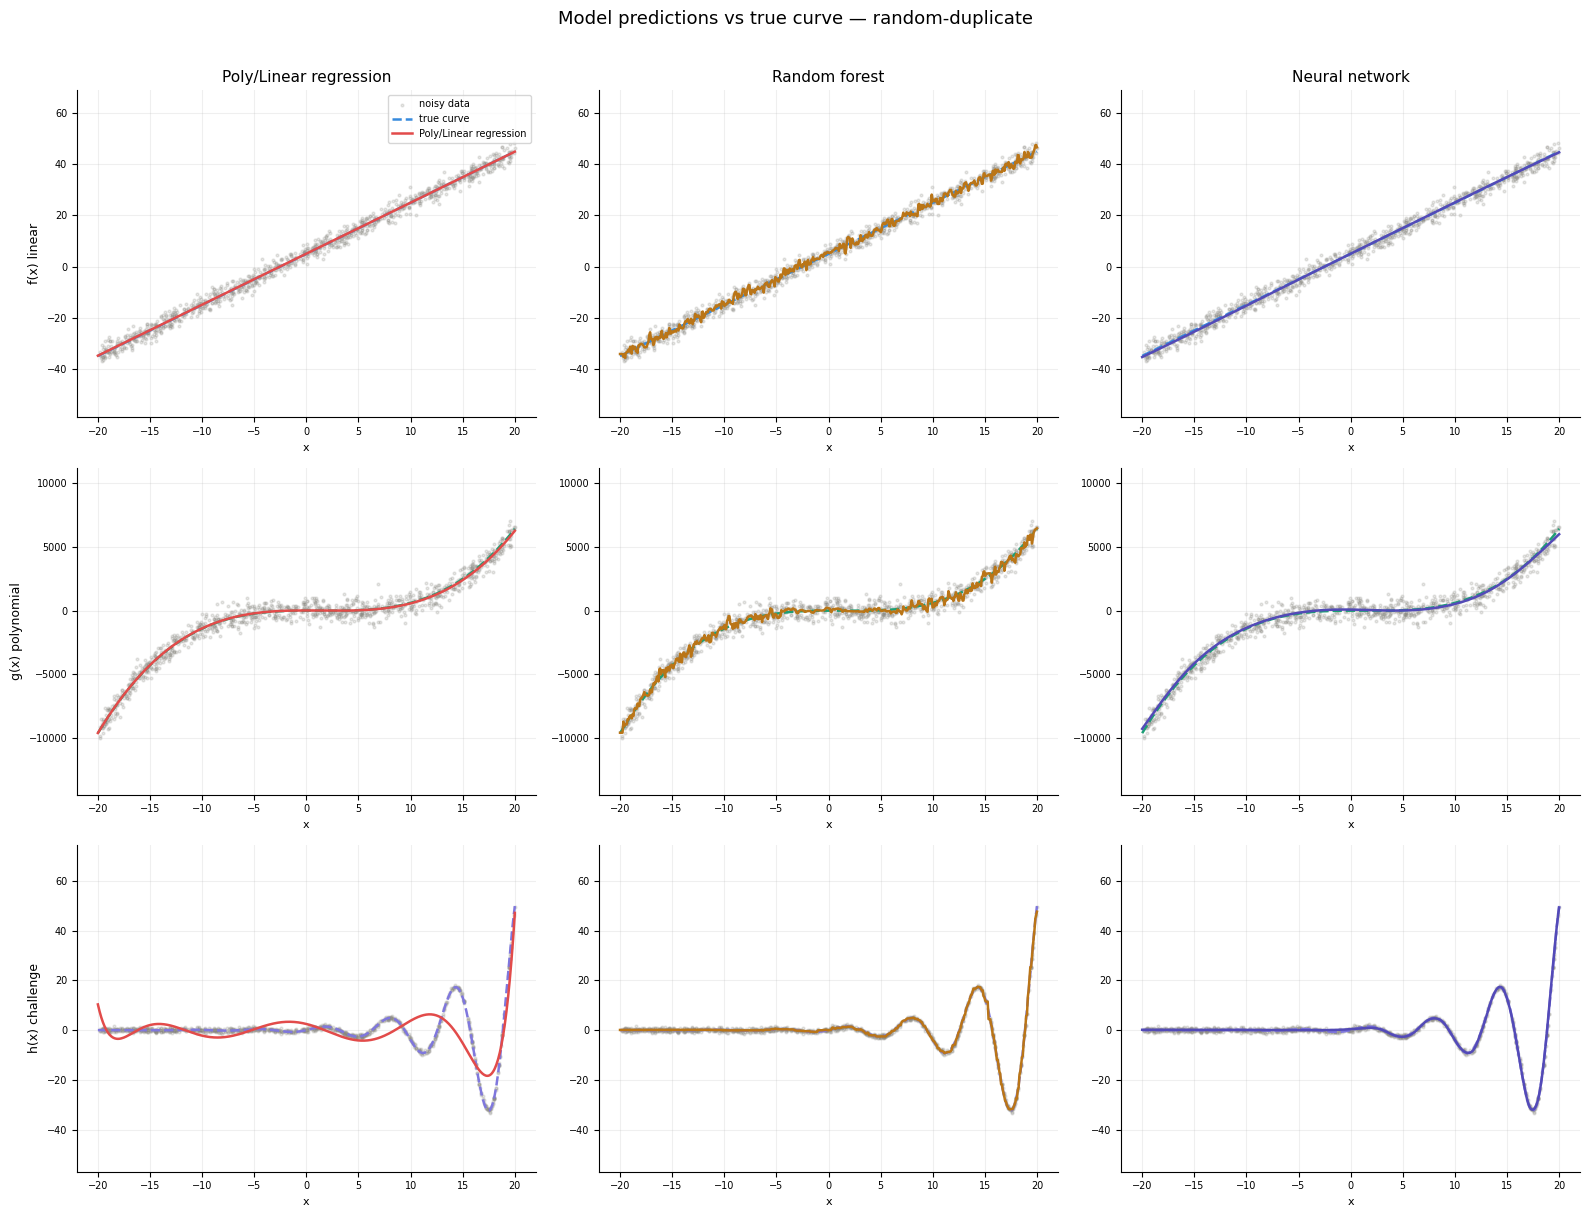

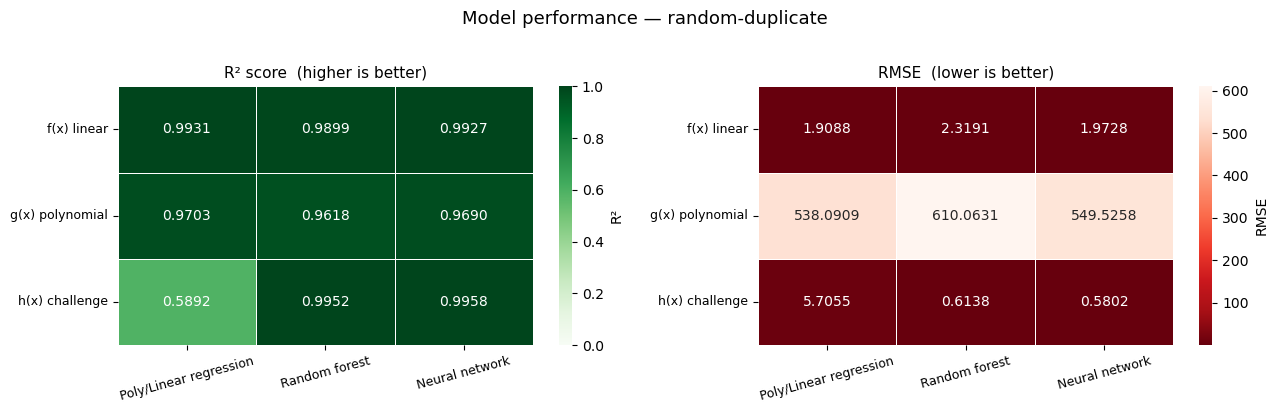


random-duplicate — R² scores:
                  Poly/Linear regression  Random forest  Neural network
f(x) linear                      0.9931         0.9899          0.9927
g(x) polynomial                  0.9703         0.9618          0.9690
h(x) challenge                   0.5892         0.9952          0.9958

random-duplicate — RMSE scores:
                  Poly/Linear regression  Random forest  Neural network
f(x) linear                      1.9088         2.3191          1.9728
g(x) polynomial                538.0909       610.0631        549.5258
h(x) challenge                   5.7055         0.6138          0.5802


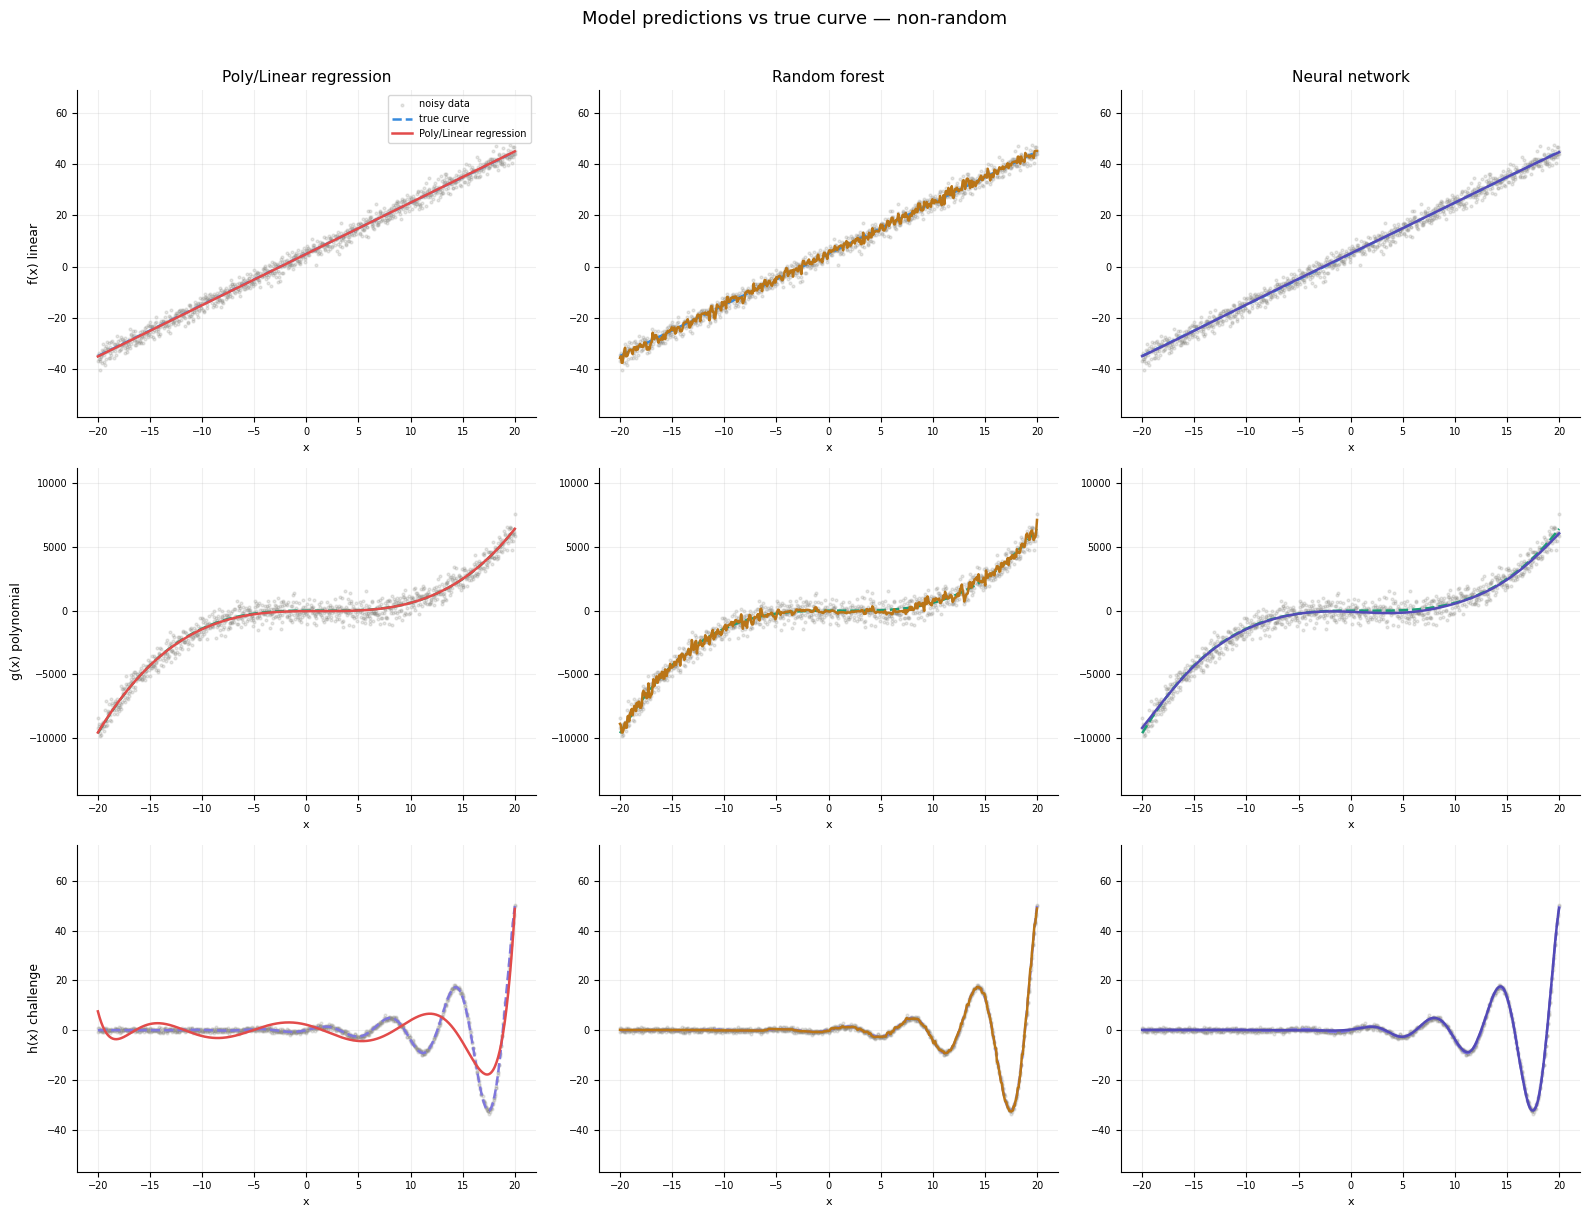

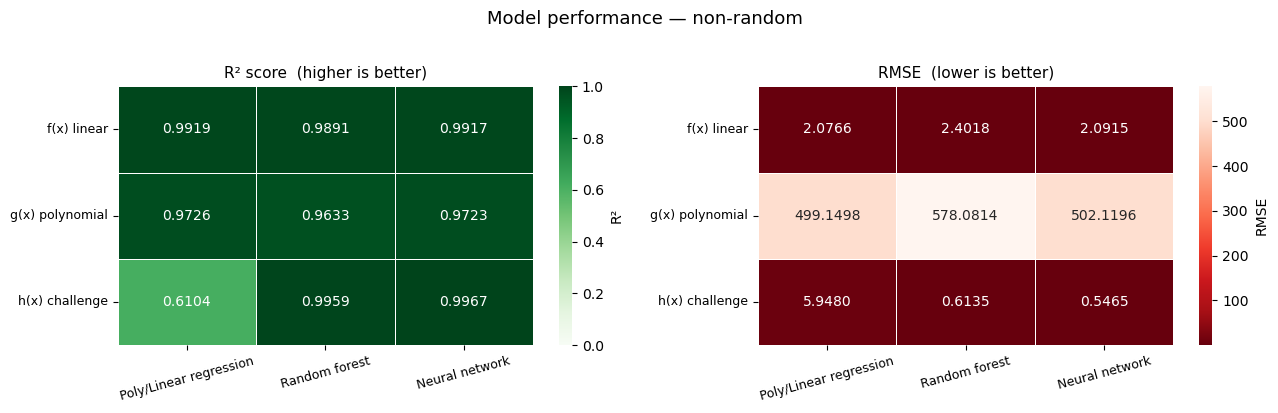


non-random — R² scores:
                  Poly/Linear regression  Random forest  Neural network
f(x) linear                      0.9919         0.9891          0.9917
g(x) polynomial                  0.9726         0.9633          0.9723
h(x) challenge                   0.6104         0.9959          0.9967

non-random — RMSE scores:
                  Poly/Linear regression  Random forest  Neural network
f(x) linear                      2.0766         2.4018          2.0915
g(x) polynomial                499.1498       578.0814        502.1196
h(x) challenge                   5.9480         0.6135          0.5465


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# --- Load the two 1000-value datasets ---
datasets = {
    'random-duplicate': pd.read_csv('random-duplicate-noisy.csv').sort_values('x').reset_index(drop=True),
    'non-random':       pd.read_csv('non-random-noisy.csv').sort_values('x').reset_index(drop=True),
}

# --- True curves ---
x_true = np.linspace(-20, 20, 500)
def true_linear(x):    return 2*x + 5
def true_poly(x):      return x**3 - 4*x**2 + x + 6
def true_challenge(x): return np.sin(x) * np.exp(x/5)

functions = {
    'f(x) linear':     'f_linear',
    'g(x) polynomial': 'g_polynomial',
    'h(x) challenge':  'h_challenge',
}

true_fns = {
    'f(x) linear':     true_linear,
    'g(x) polynomial': true_poly,
    'h(x) challenge':  true_challenge,
}

true_colors = {
    'f(x) linear':     '#378ADD',
    'g(x) polynomial': '#1D9E75',
    'h(x) challenge':  '#7F77DD',
}

poly_degrees = {
    'f(x) linear':     1,
    'g(x) polynomial': 3,
    'h(x) challenge':  8,
}

model_names  = ['Poly/Linear regression', 'Random forest', 'Neural network']
model_colors = {
    'Poly/Linear regression': '#E24B4A',
    'Random forest':          '#BA7517',
    'Neural network':         '#534AB7',
}

# ---------------------------------------------------------------
# LOOP over both datasets
# For each: fit all 3 models on all 3 functions,
# plot predictions vs true curve, output heatmaps
# ---------------------------------------------------------------
for ds_name, df in datasets.items():

    X = df[['x']].values
    x_plot = np.linspace(-20, 20, 500).reshape(-1, 1)

    r2_scores   = pd.DataFrame(index=list(functions.keys()), columns=model_names, dtype=float)
    rmse_scores = pd.DataFrame(index=list(functions.keys()), columns=model_names, dtype=float)

    # --- Prediction plot: 3 rows x 3 cols ---
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    fig.suptitle(f'Model predictions vs true curve — {ds_name}',
                 fontsize=13, fontweight='normal', y=1.01)

    for row, (fn_label, col_name) in enumerate(functions.items()):

        y = df[col_name].values
        true_fn = true_fns[fn_label]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        # Scale for neural network
        x_scaler = StandardScaler()
        y_scaler = StandardScaler()
        X_train_sc = x_scaler.fit_transform(X_train)
        X_test_sc  = x_scaler.transform(X_test)
        y_train_sc = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()

        # --- Fit models ---
        m1 = make_pipeline(PolynomialFeatures(degree=poly_degrees[fn_label]), LinearRegression())
        m1.fit(X_train, y_train)

        m2 = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42)
        m2.fit(X_train, y_train)

        m3 = MLPRegressor(
            hidden_layer_sizes=(128, 128, 64), activation='tanh',
            max_iter=20000, random_state=42, learning_rate='adaptive',
            learning_rate_init=0.001, early_stopping=True,
            validation_fraction=0.1, n_iter_no_change=100, tol=1e-6,
        )
        m3.fit(X_train_sc, y_train_sc)

        # --- Predictions on test set for scoring ---
        preds_m1 = m1.predict(X_test)
        preds_m2 = m2.predict(X_test)
        preds_m3 = y_scaler.inverse_transform(
            m3.predict(X_test_sc).reshape(-1, 1)
        ).ravel()

        # --- Predictions on full x_plot for graphing ---
        plot_m1 = m1.predict(x_plot)
        plot_m2 = m2.predict(x_plot)
        plot_m3 = y_scaler.inverse_transform(
            m3.predict(x_scaler.transform(x_plot)).reshape(-1, 1)
        ).ravel()

        plot_preds = {
            'Poly/Linear regression': plot_m1,
            'Random forest':          plot_m2,
            'Neural network':         plot_m3,
        }

        # --- Score ---
        for mname, preds in zip(model_names, [preds_m1, preds_m2, preds_m3]):
            r2_scores.loc[fn_label, mname]   = round(r2_score(y_test, preds), 4)
            rmse_scores.loc[fn_label, mname] = round(np.sqrt(mean_squared_error(y_test, preds)), 4)

        # --- Plot each model ---
        for col, (mname, pred) in enumerate(plot_preds.items()):
            ax = axes[row][col]

            # Noisy scatter
            ax.scatter(X, y, color='#888780', alpha=0.2, s=4, label='noisy data')

            # True curve
            ax.plot(x_plot, true_fn(x_plot.ravel()),
                    color=true_colors[fn_label], linewidth=1.8,
                    linestyle='--', label='true curve')

            # Model prediction
            ax.plot(x_plot, pred, color=model_colors[mname],
                    linewidth=1.8, label=mname)

            if row == 0:
                ax.set_title(mname, fontsize=11, fontweight='normal')
            if col == 0:
                ax.set_ylabel(fn_label, fontsize=9)

            ax.set_xlabel('x', fontsize=8)
            ax.tick_params(labelsize=7)
            ax.grid(True, alpha=0.2)
            ax.spines[['top', 'right']].set_visible(False)

            y_true_vals = true_fn(x_plot.ravel())
            margin = (y_true_vals.max() - y_true_vals.min()) * 0.3
            ax.set_ylim(y_true_vals.min() - margin, y_true_vals.max() + margin)

            if row == 0 and col == 0:
                ax.legend(fontsize=7)

    plt.tight_layout()
    plt.savefig(f'model_predictions_{ds_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    # --- Heatmaps ---
    fig, axes_h = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Model performance — {ds_name}', fontsize=13, fontweight='normal', y=1.02)

    sns.heatmap(r2_scores.astype(float), ax=axes_h[0],
                annot=True, fmt='.4f', cmap='Greens',
                vmin=0, vmax=1,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'R²'})
    axes_h[0].set_title('R² score  (higher is better)', fontsize=11, fontweight='normal')
    axes_h[0].tick_params(axis='x', rotation=15, labelsize=9)
    axes_h[0].tick_params(axis='y', rotation=0,  labelsize=9)

    sns.heatmap(rmse_scores.astype(float), ax=axes_h[1],
                annot=True, fmt='.4f', cmap='Reds_r',
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'RMSE'})
    axes_h[1].set_title('RMSE  (lower is better)', fontsize=11, fontweight='normal')
    axes_h[1].tick_params(axis='x', rotation=15, labelsize=9)
    axes_h[1].tick_params(axis='y', rotation=0,  labelsize=9)

    plt.tight_layout()
    plt.savefig(f'heatmap_{ds_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n{ds_name} — R² scores:\n', r2_scores)
    print(f'\n{ds_name} — RMSE scores:\n', rmse_scores)